In [1]:
import sys
print(sys.executable)

import mediapipe as mp
import cv2
print("MediaPipe version:", mp.__version__)
print("OpenCV version:", cv2.__version__)

c:\Users\demki\miniconda3\envs\easymotion\python.exe
MediaPipe version: 0.10.14
OpenCV version: 5.0.0


In [2]:
import cv2
import mediapipe as mp

mp_pose = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils

pose = mp_pose.Pose(static_image_mode=True)

image = cv2.imread("test_photo.jpg")
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

results = pose.process(image_rgb)

if results.pose_landmarks:
    print("Pose detected!")
    print("Number of landmarks:", len(results.pose_landmarks.landmark))
else:
    print("No pose detected")

Pose detected!
Number of landmarks: 33


c:\Users\demki\miniconda3\envs\easymotion\lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


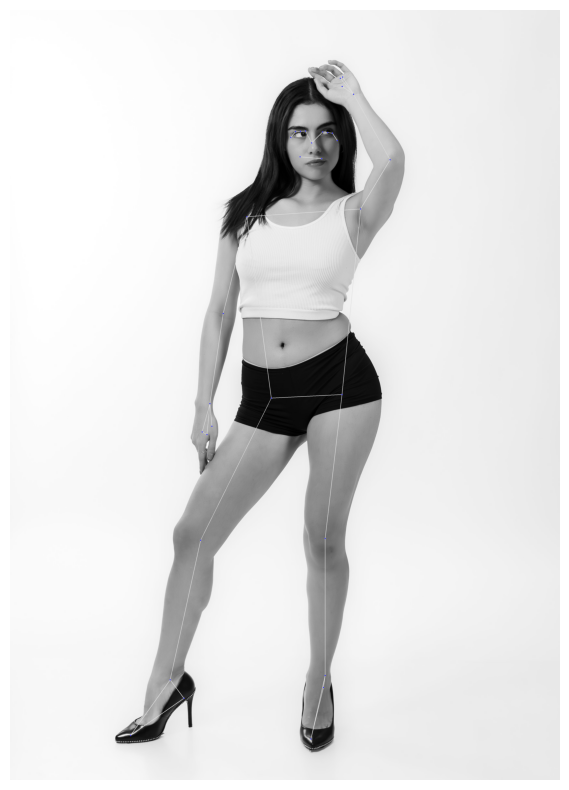

In [3]:
import matplotlib.pyplot as plt

annotated_image = image_rgb.copy()

mp_drawing.draw_landmarks(
    annotated_image,
    results.pose_landmarks,
    mp_pose.POSE_CONNECTIONS
)

plt.figure(figsize=(8, 10))
plt.imshow(annotated_image)
plt.axis("off")
plt.show()

In [4]:
cap = cv2.VideoCapture("test_video.mp4")

frame_count = 0
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    frame_count += 1

cap.release()
print("Total frames:", frame_count)

Total frames: 266


In [5]:
cap = cv2.VideoCapture("test_video.mp4")

ret, frame = cap.read()
cap.release()

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

pose_video = mp_pose.Pose(static_image_mode=False)
results = pose_video.process(frame_rgb)

if results.pose_landmarks:
    print("Pose detected in first frame!")
else:
    print("No pose detected in first frame")

Pose detected in first frame!


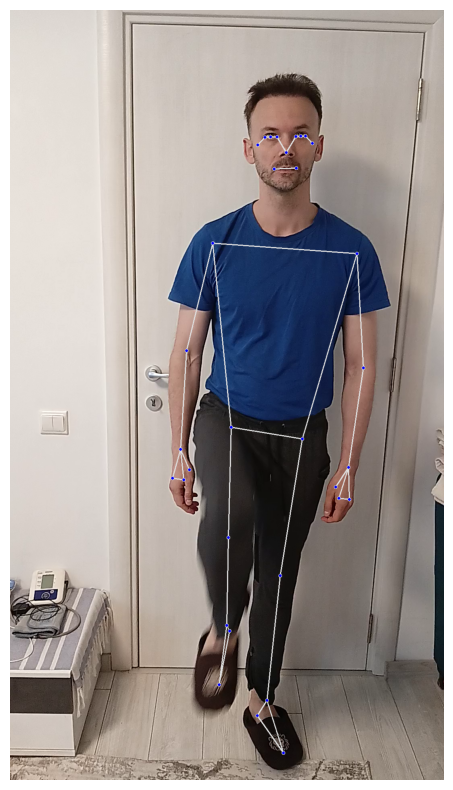

In [6]:
annotated_frame = frame_rgb.copy()

mp_drawing.draw_landmarks(
    annotated_frame,
    results.pose_landmarks,
    mp_pose.POSE_CONNECTIONS
)

plt.figure(figsize=(8, 10))
plt.imshow(annotated_frame)
plt.axis("off")
plt.show()

In [7]:
def extract_landmarks_from_video(video_path, pose_model):
    cap = cv2.VideoCapture(video_path)
    all_landmarks = []

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = pose_model.process(frame_rgb)

        if results.pose_landmarks:
            frame_landmarks = [(lm.x, lm.y, lm.z, lm.visibility) for lm in results.pose_landmarks.landmark]
        else:
            frame_landmarks = None

        all_landmarks.append(frame_landmarks)

    cap.release()
    return all_landmarks

In [8]:
pose_model = mp_pose.Pose(static_image_mode=False)
landmarks_sequence = extract_landmarks_from_video("test_video.mp4", pose_model)

print("Total frames processed:", len(landmarks_sequence))
print("Frames with detected pose:", sum(1 for f in landmarks_sequence if f is not None))
print("Landmarks in first detected frame:", len(landmarks_sequence[0]) if landmarks_sequence[0] else "None")

Total frames processed: 266
Frames with detected pose: 266
Landmarks in first detected frame: 33


In [9]:
import numpy as np

def landmarks_to_array(landmarks_sequence):
    num_frames = len(landmarks_sequence)
    num_landmarks = 33
    arr = np.zeros((num_frames, num_landmarks, 4))

    for i, frame_landmarks in enumerate(landmarks_sequence):
        if frame_landmarks is not None:
            arr[i] = np.array(frame_landmarks)

    return arr

landmarks_array = landmarks_to_array(landmarks_sequence)
print("Shape:", landmarks_array.shape)

Shape: (266, 33, 4)


In [10]:
pose_model_2 = mp_pose.Pose(static_image_mode=False)
landmarks_sequence_2 = extract_landmarks_from_video("test_video_2.mp4", pose_model_2)
landmarks_array_2 = landmarks_to_array(landmarks_sequence_2)

print("Video 2 shape:", landmarks_array_2.shape)

Video 2 shape: (266, 33, 4)


In [11]:
print("Are the two videos identical?", np.array_equal(landmarks_array, landmarks_array_2))

Are the two videos identical? False


In [12]:
LANDMARK_NAMES = {
    11: "left_shoulder", 12: "right_shoulder",
    13: "left_elbow", 14: "right_elbow",
    15: "left_wrist", 16: "right_wrist",
    23: "left_hip", 24: "right_hip",
    25: "left_knee", 26: "right_knee",
    27: "left_ankle", 28: "right_ankle",
}

def calculate_angle(a, b, c):
    a, b, c = np.array(a), np.array(b), np.array(c)
    ba = a - b
    bc = c - b
    cosine_angle = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-8)
    angle = np.degrees(np.arccos(np.clip(cosine_angle, -1.0, 1.0)))
    return angle

def get_joint_angle_sequence(landmarks_array, point_a_idx, point_b_idx, point_c_idx):
    angles = []
    for frame in landmarks_array:
        a = frame[point_a_idx][:2]
        b = frame[point_b_idx][:2]
        c = frame[point_c_idx][:2]
        angles.append(calculate_angle(a, b, c))
    return np.array(angles)

left_elbow_angles_v1 = get_joint_angle_sequence(landmarks_array, 11, 13, 15)
print("Left elbow angle sequence shape:", left_elbow_angles_v1.shape)
print("First 10 angles:", left_elbow_angles_v1[:10])

Left elbow angle sequence shape: (266,)
First 10 angles: [159.72905708 159.94596268 159.96694831 159.69147264 158.20268402
 156.78320731 155.64709251 155.49456473 156.70446289 157.27557895]


In [13]:
left_elbow_angles_v2 = get_joint_angle_sequence(landmarks_array_2, 11, 13, 15)

left_knee_angles_v1 = get_joint_angle_sequence(landmarks_array, 23, 25, 27)
left_knee_angles_v2 = get_joint_angle_sequence(landmarks_array_2, 23, 25, 27)

print("V2 elbow angles shape:", left_elbow_angles_v2.shape)
print("V1 knee angles shape:", left_knee_angles_v1.shape)

V2 elbow angles shape: (266,)
V1 knee angles shape: (266,)


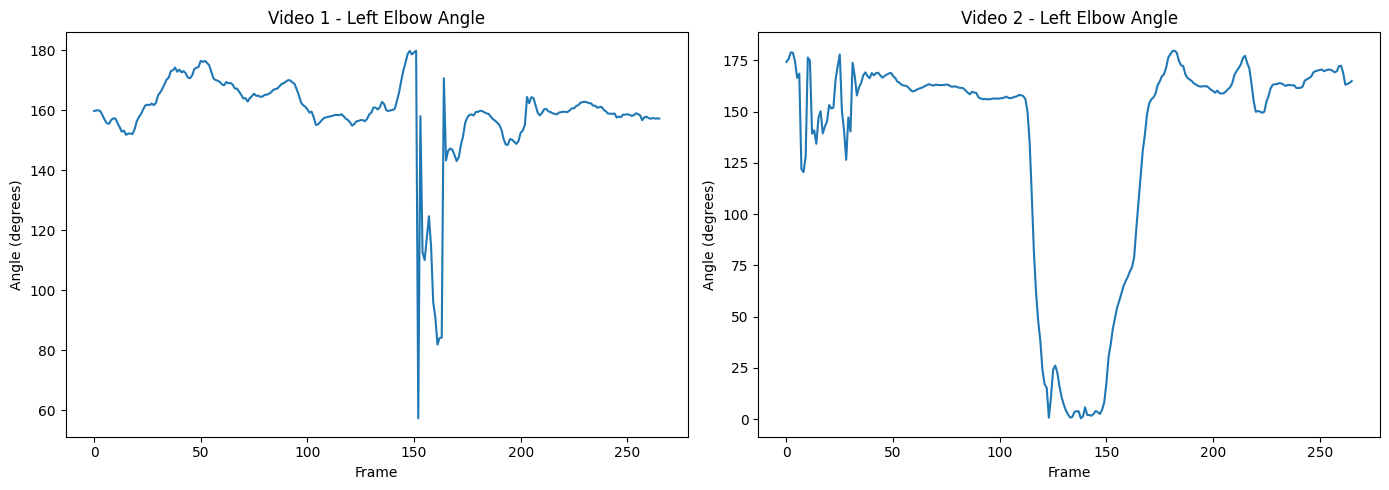

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(left_elbow_angles_v1)
axes[0].set_title("Video 1 - Left Elbow Angle")
axes[0].set_xlabel("Frame")
axes[0].set_ylabel("Angle (degrees)")

axes[1].plot(left_elbow_angles_v2)
axes[1].set_title("Video 2 - Left Elbow Angle")
axes[1].set_xlabel("Frame")
axes[1].set_ylabel("Angle (degrees)")

plt.tight_layout()
plt.show()

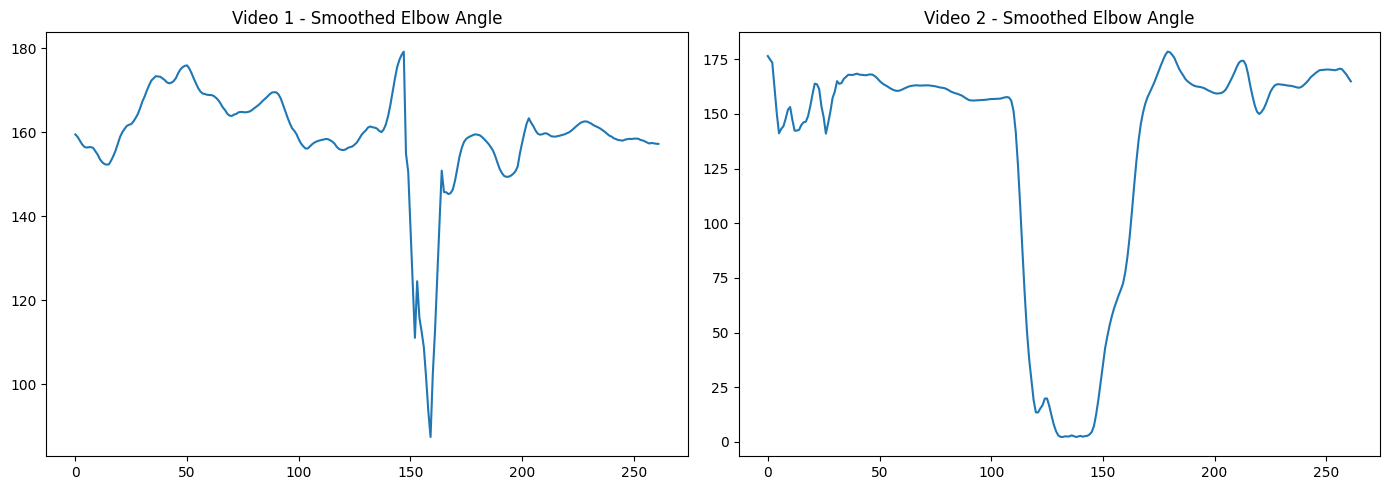

In [15]:
def smooth_sequence(sequence, window_size=5):
    return np.convolve(sequence, np.ones(window_size)/window_size, mode='valid')

left_elbow_v1_smooth = smooth_sequence(left_elbow_angles_v1)
left_elbow_v2_smooth = smooth_sequence(left_elbow_angles_v2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(left_elbow_v1_smooth)
axes[0].set_title("Video 1 - Smoothed Elbow Angle")
axes[1].plot(left_elbow_v2_smooth)
axes[1].set_title("Video 2 - Smoothed Elbow Angle")
plt.tight_layout()
plt.show()

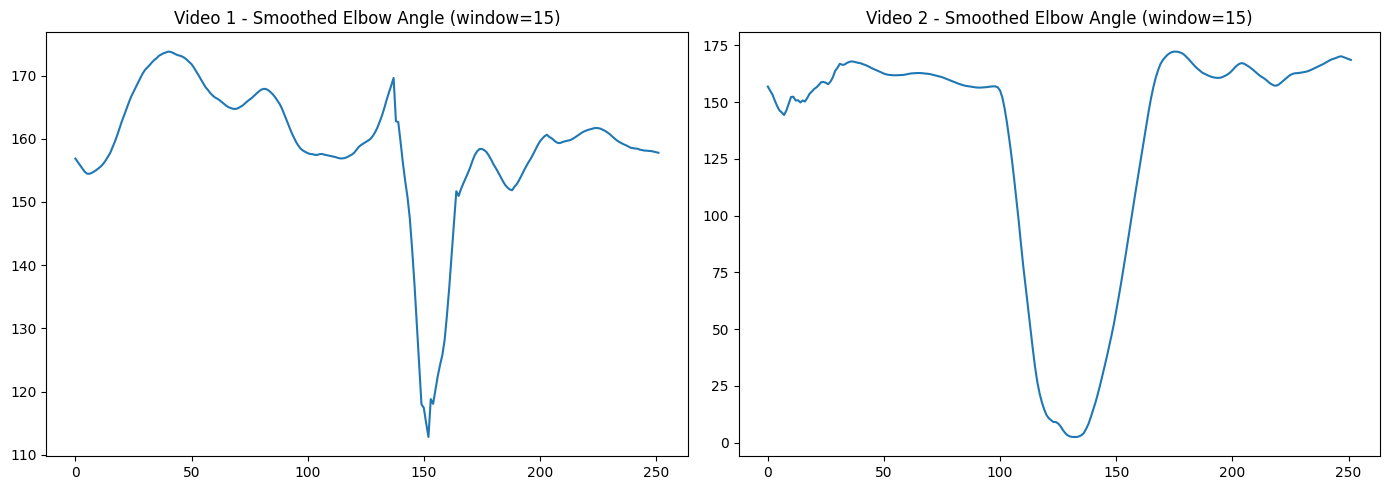

In [16]:
left_elbow_v1_smooth = smooth_sequence(left_elbow_angles_v1, window_size=15)
left_elbow_v2_smooth = smooth_sequence(left_elbow_angles_v2, window_size=15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(left_elbow_v1_smooth)
axes[0].set_title("Video 1 - Smoothed Elbow Angle (window=15)")
axes[1].plot(left_elbow_v2_smooth)
axes[1].set_title("Video 2 - Smoothed Elbow Angle (window=15)")
plt.tight_layout()
plt.show()

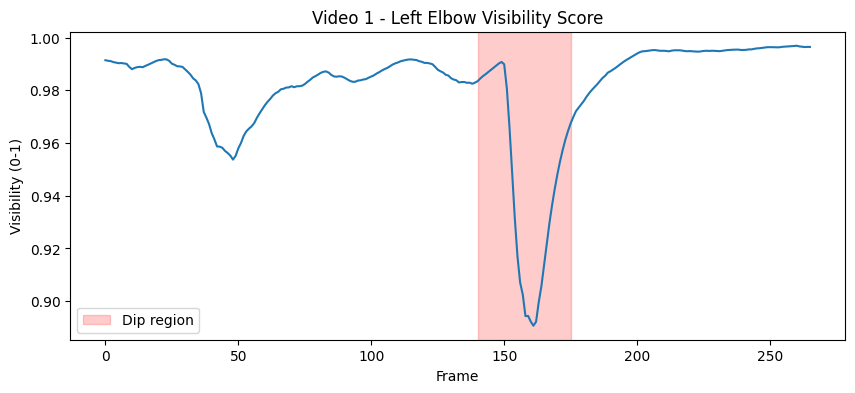

In [17]:
elbow_visibility_v1 = landmarks_array[:, 13, 3]  # landmark 13 = left elbow, index 3 = visibility

plt.figure(figsize=(10, 4))
plt.plot(elbow_visibility_v1)
plt.title("Video 1 - Left Elbow Visibility Score")
plt.xlabel("Frame")
plt.ylabel("Visibility (0-1)")
plt.axvspan(140, 175, color='red', alpha=0.2, label="Dip region")
plt.legend()
plt.show()

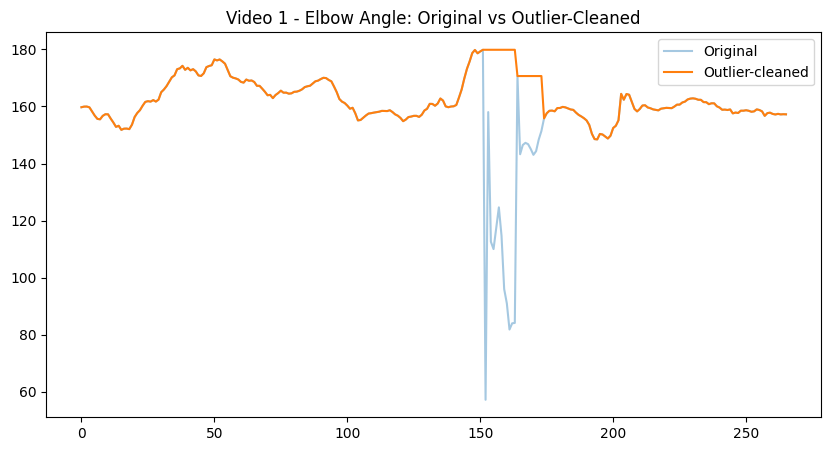

In [18]:
def remove_angle_outliers(angle_sequence, max_change_per_frame=15):
    cleaned = angle_sequence.copy()
    for i in range(1, len(cleaned)):
        if abs(cleaned[i] - cleaned[i-1]) > max_change_per_frame:
            cleaned[i] = cleaned[i-1]  # hold previous value instead of the implausible jump
    return cleaned

left_elbow_v1_cleaned = remove_angle_outliers(left_elbow_angles_v1)

plt.figure(figsize=(10, 5))
plt.plot(left_elbow_angles_v1, alpha=0.4, label="Original")
plt.plot(left_elbow_v1_cleaned, label="Outlier-cleaned")
plt.legend()
plt.title("Video 1 - Elbow Angle: Original vs Outlier-Cleaned")
plt.show()

In [19]:
left_elbow_v1_cleaned = remove_angle_outliers(left_elbow_angles_v1)
left_elbow_v2_cleaned = remove_angle_outliers(left_elbow_angles_v2)
left_knee_v1_cleaned = remove_angle_outliers(left_knee_angles_v1)
left_knee_v2_cleaned = remove_angle_outliers(left_knee_angles_v2)

In [23]:
%pip install fastdtw

  Using cached fastdtw-0.3.4.tar.gz (133 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for fastdtw: filename=fastdtw-0.3.4-py3-none-any.whl size=3631 sha256=722fbe14bf7a876b2281bba296028aa206c159b848e599a6b0557fb5535c33c5
  Stored in directory: c:\users\demki\appdata\local\pip\cache\wheels\73\c8\f7\c25448dab74c3acf4848bc25d513c736bb93910277e1528ef4
Successfully built fastdtw
Note: you may need to restart the kernel to use updated packages.


In [25]:
from fastdtw import fastdtw

def simple_dist(a, b):
    return abs(a - b)

distance, path = fastdtw(left_elbow_v1_cleaned, left_elbow_v2_cleaned, dist=simple_dist)

print("DTW distance:", distance)
print("Alignment path length:", len(path))

DTW distance: 2317.798260951679
Alignment path length: 401


In [26]:
distance_self, _ = fastdtw(left_elbow_v1_cleaned, left_elbow_v1_cleaned, dist=simple_dist)
print("DTW distance (video 1 vs itself):", distance_self)

DTW distance (video 1 vs itself): 0.0


In [27]:
normalized_distance = distance / len(path)
print("Normalized DTW distance:", normalized_distance)

Normalized DTW distance: 5.780045538532865


In [28]:
max_possible_diff = 180  # max possible angle difference
similarity_score = max(0, 100 - (normalized_distance / max_possible_diff * 100))
print(f"Similarity score: {similarity_score:.1f}%")

Similarity score: 96.8%
